In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Load the main dataset
df = pd.read_csv('secom.data', sep=' ', header=None)

# Load the labels
labels = pd.read_csv('secom_labels.data', sep=' ', header=None)
labels.columns = ['result', 'timestamp']

# Basic overview
print("Dataset shape:", df.shape)
print("Labels shape:", labels.shape)
print("\nFirst look at labels:")
print(labels['result'].value_counts())

Dataset shape: (1567, 590)
Labels shape: (1567, 2)

First look at labels:
result
-1    1463
 1     104
Name: count, dtype: int64


In [3]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

print("Total columns:", len(df.columns))
print("Columns with missing values:", (missing > 0).sum())
print("\nTop 10 columns with most missing data:")
print(missing_pct.sort_values(ascending=False).head(10))

Total columns: 590
Columns with missing values: 538

Top 10 columns with most missing data:
292    91.193363
293    91.193363
158    91.193363
157    91.193363
492    85.577537
85     85.577537
358    85.577537
220    85.577537
244    64.964901
517    64.964901
dtype: float64


In [4]:
# Drop columns with more than 50% missing data
threshold = 0.5
df_clean = df.dropna(axis=1, thresh=int(threshold * len(df)))

print("Columns before cleaning:", df.shape[1])
print("Columns after cleaning:", df_clean.shape[1])
print("Columns dropped:", df.shape[1] - df_clean.shape[1])

# Fill remaining missing values with column mean
df_clean = df_clean.fillna(df_clean.mean())

# Add labels to cleaned dataframe
df_clean['result'] = labels['result'].values

print("\nMissing values remaining:", df_clean.isnull().sum().sum())
print("Final dataset shape:", df_clean.shape)

Columns before cleaning: 590
Columns after cleaning: 562
Columns dropped: 28

Missing values remaining: 0
Final dataset shape: (1567, 563)


C:\Users\sidsa\AppData\Local\Temp\ipykernel_24652\3242077626.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['result'] = labels['result'].values


In [5]:
# Fix fragmentation warning and reset clean dataframe
df_clean = df_clean.copy()

print("Dataset is clean and ready!")
print("Shape:", df_clean.shape)
print("Pass (-1):", (df_clean['result'] == -1).sum())
print("Fail (1):", (df_clean['result'] == 1).sum())

Dataset is clean and ready!
Shape: (1567, 563)
Pass (-1): 1463
Fail (1): 104


In [6]:
# Separate features and result
X = df_clean.drop('result', axis=1)
y = df_clean['result']

# Remove low variance columns
variance = X.var()
low_variance = variance[variance < 0.01].index
X_filtered = X.drop(columns=low_variance)

print("Columns before variance filter:", X.shape[1])
print("Columns removed (low variance):", len(low_variance))
print("Columns remaining:", X_filtered.shape[1])

Columns before variance filter: 562
Columns removed (low variance): 265
Columns remaining: 297


In [7]:
# Find correlation of each parameter with pass/fail result
correlation = X_filtered.corrwith(y).abs()
correlation = correlation.sort_values(ascending=False)

print("Top 20 parameters most correlated with failures:")
print(correlation.head(20))

# Keep only top 40 most correlated features for SPC analysis
top_features = correlation.head(40).index.tolist()
X_final = X_filtered[top_features]

print("\nFinal number of parameters for SPC analysis:", X_final.shape[1])

Top 20 parameters most correlated with failures:
59     0.155771
510    0.131587
431    0.120304
434    0.111609
430    0.109569
435    0.108573
21     0.107997
28     0.106767
436    0.106426
129    0.103351
163    0.099876
124    0.093974
295    0.091831
160    0.089689
316    0.089410
164    0.087648
299    0.087634
300    0.084438
125    0.083874
165    0.083866
dtype: float64

Final number of parameters for SPC analysis: 40


In [8]:
# Select our most important parameter
param = 59
data = X_final[param].values

# Define subgroup size
subgroup_size = 5
n_subgroups = len(data) // subgroup_size

# Create subgroups
subgroups = data[:n_subgroups * subgroup_size].reshape(n_subgroups, subgroup_size)

# Calculate subgroup means and ranges
xbar = subgroups.mean(axis=1)
ranges = subgroups.max(axis=1) - subgroups.min(axis=1)

# Control chart constants for n=5
A2 = 0.577
D3 = 0
D4 = 2.114

# Calculate control limits
xbar_mean = xbar.mean()
r_mean = ranges.mean()

UCL_xbar = xbar_mean + A2 * r_mean
LCL_xbar = xbar_mean - A2 * r_mean
UCL_r = D4 * r_mean
LCL_r = D3 * r_mean

print("X-bar Chart:")
print(f"  Center Line: {xbar_mean:.4f}")
print(f"  UCL: {UCL_xbar:.4f}")
print(f"  LCL: {LCL_xbar:.4f}")
print("\nR Chart:")
print(f"  Center Line: {r_mean:.4f}")
print(f"  UCL: {UCL_r:.4f}")
print(f"  LCL: {LCL_r:.4f}")

X-bar Chart:
  Center Line: 2.9600
  UCL: 10.5322
  LCL: -4.6122

R Chart:
  Center Line: 13.1234
  UCL: 27.7428
  LCL: 0.0000


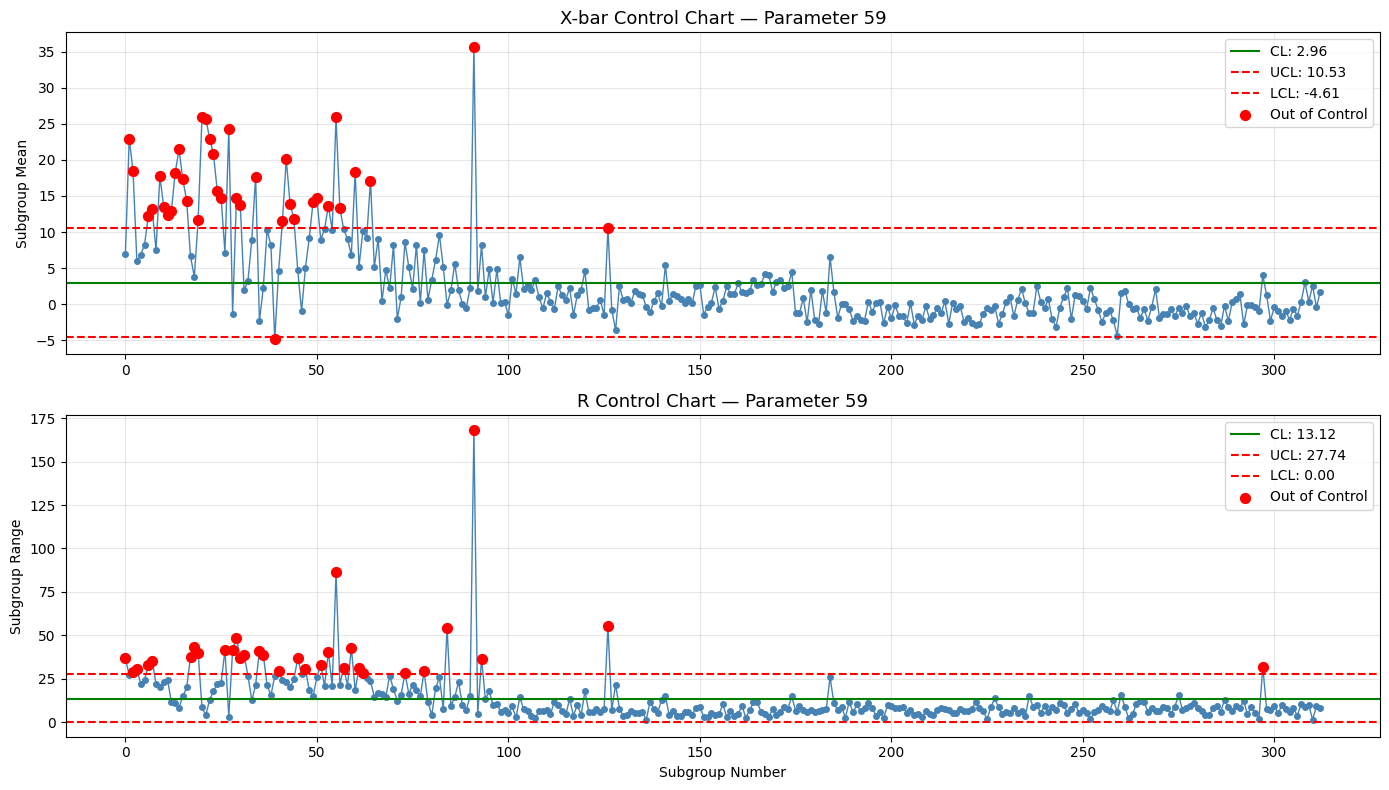


Out of control points (X-bar): 37
Out of control points (R): 32


In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# X-bar chart
ax1.plot(xbar, marker='o', markersize=4, color='steelblue', linewidth=1)
ax1.axhline(xbar_mean, color='green', linewidth=1.5, label=f'CL: {xbar_mean:.2f}')
ax1.axhline(UCL_xbar, color='red', linewidth=1.5, linestyle='--', label=f'UCL: {UCL_xbar:.2f}')
ax1.axhline(LCL_xbar, color='red', linewidth=1.5, linestyle='--', label=f'LCL: {LCL_xbar:.2f}')

# Highlight out of control points
ooc_xbar = (xbar > UCL_xbar) | (xbar < LCL_xbar)
ax1.scatter(np.where(ooc_xbar)[0], xbar[ooc_xbar], color='red', zorder=5, s=50, label='Out of Control')

ax1.set_title(f'X-bar Control Chart — Parameter {param}', fontsize=13)
ax1.set_ylabel('Subgroup Mean')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# R chart
ax2.plot(ranges, marker='o', markersize=4, color='steelblue', linewidth=1)
ax2.axhline(r_mean, color='green', linewidth=1.5, label=f'CL: {r_mean:.2f}')
ax2.axhline(UCL_r, color='red', linewidth=1.5, linestyle='--', label=f'UCL: {UCL_r:.2f}')
ax2.axhline(LCL_r, color='red', linewidth=1.5, linestyle='--', label=f'LCL: {LCL_r:.2f}')

ooc_r = (ranges > UCL_r) | (ranges < LCL_r)
ax2.scatter(np.where(ooc_r)[0], ranges[ooc_r], color='red', zorder=5, s=50, label='Out of Control')

ax2.set_title(f'R Control Chart — Parameter {param}', fontsize=13)
ax2.set_ylabel('Subgroup Range')
ax2.set_xlabel('Subgroup Number')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xbar_r_chart_param59.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOut of control points (X-bar): {ooc_xbar.sum()}")
print(f"Out of control points (R): {ooc_r.sum()}")

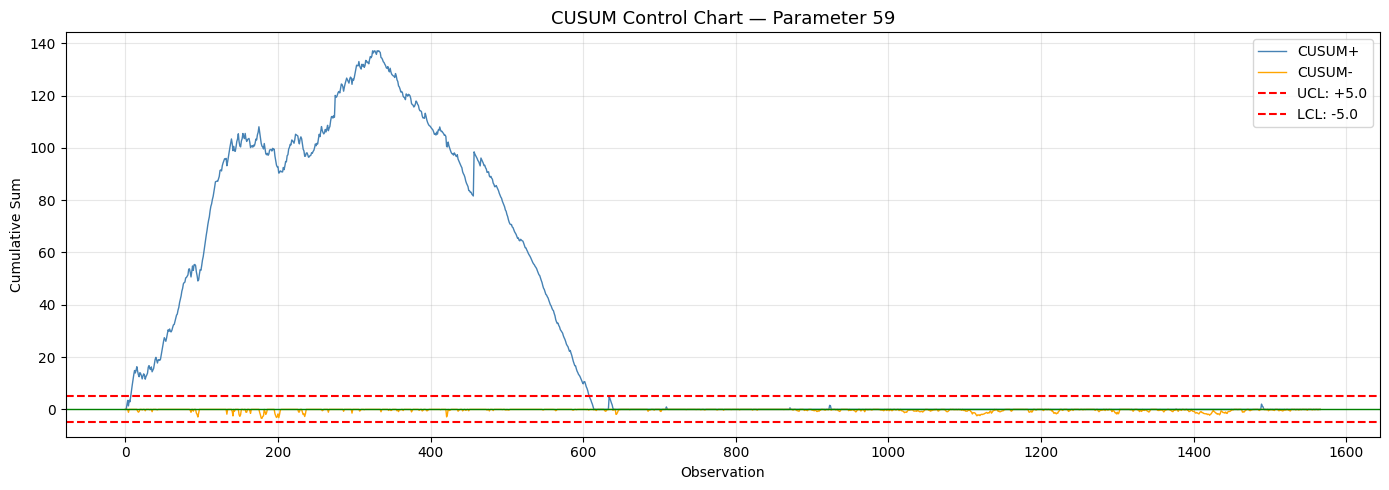

In [10]:
# CUSUM Chart for Parameter 59
k = 0.5  # allowable slack (half of sigma)
h = 5.0  # decision interval

# Standardise the data
data_std = (data - data.mean()) / data.std()

# Calculate CUSUM
cusum_pos = np.zeros(len(data_std))
cusum_neg = np.zeros(len(data_std))

for i in range(1, len(data_std)):
    cusum_pos[i] = max(0, cusum_pos[i-1] + data_std[i] - k)
    cusum_neg[i] = min(0, cusum_neg[i-1] + data_std[i] + k)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(cusum_pos, color='steelblue', linewidth=1, label='CUSUM+')
ax.plot(cusum_neg, color='orange', linewidth=1, label='CUSUM-')
ax.axhline(h, color='red', linestyle='--', linewidth=1.5, label=f'UCL: +{h}')
ax.axhline(-h, color='red', linestyle='--', linewidth=1.5, label=f'LCL: -{h}')
ax.axhline(0, color='green', linewidth=1, linestyle='-')

ax.set_title(f'CUSUM Control Chart — Parameter {param}', fontsize=13)
ax.set_xlabel('Observation')
ax.set_ylabel('Cumulative Sum')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cusum_chart_param59.png', dpi=150, bbox_inches='tight')
plt.show()

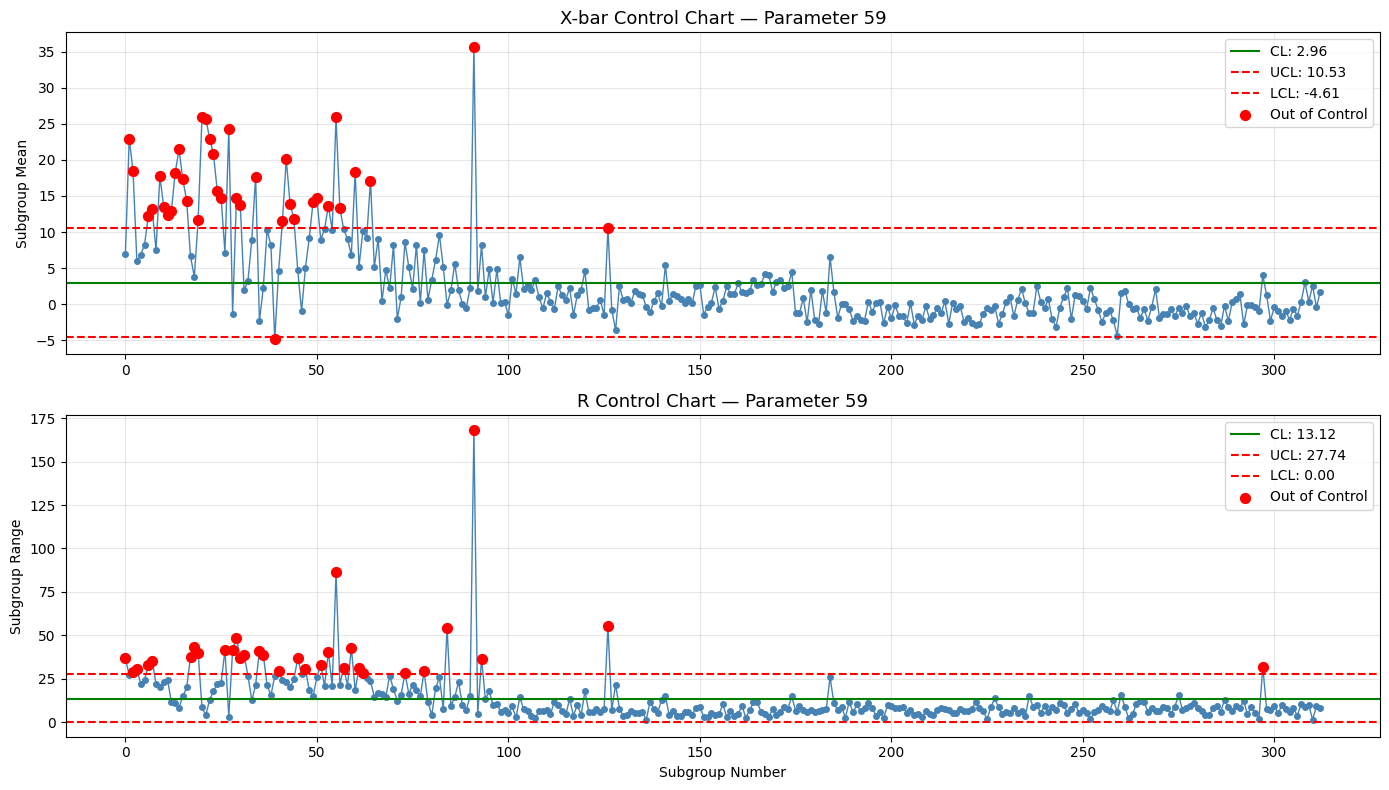


Out of control points (X-bar): 37
Out of control points (R): 32


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# X-bar chart
ax1.plot(xbar, marker='o', markersize=4, color='steelblue', linewidth=1)
ax1.axhline(xbar_mean, color='green', linewidth=1.5, label=f'CL: {xbar_mean:.2f}')
ax1.axhline(UCL_xbar, color='red', linewidth=1.5, linestyle='--', label=f'UCL: {UCL_xbar:.2f}')
ax1.axhline(LCL_xbar, color='red', linewidth=1.5, linestyle='--', label=f'LCL: {LCL_xbar:.2f}')

ooc_xbar = (xbar > UCL_xbar) | (xbar < LCL_xbar)
ax1.scatter(np.where(ooc_xbar)[0], xbar[ooc_xbar], color='red', zorder=5, s=50, label='Out of Control')

ax1.set_title(f'X-bar Control Chart — Parameter {param}', fontsize=13)
ax1.set_ylabel('Subgroup Mean')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# R chart
ax2.plot(ranges, marker='o', markersize=4, color='steelblue', linewidth=1)
ax2.axhline(r_mean, color='green', linewidth=1.5, label=f'CL: {r_mean:.2f}')
ax2.axhline(UCL_r, color='red', linewidth=1.5, linestyle='--', label=f'UCL: {UCL_r:.2f}')
ax2.axhline(LCL_r, color='red', linewidth=1.5, linestyle='--', label=f'LCL: {LCL_r:.2f}')

ooc_r = (ranges > UCL_r) | (ranges < LCL_r)
ax2.scatter(np.where(ooc_r)[0], ranges[ooc_r], color='red', zorder=5, s=50, label='Out of Control')

ax2.set_title(f'R Control Chart — Parameter {param}', fontsize=13)
ax2.set_ylabel('Subgroup Range')
ax2.set_xlabel('Subgroup Number')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xbar_r_chart_param59.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOut of control points (X-bar): {ooc_xbar.sum()}")
print(f"Out of control points (R): {ooc_r.sum()}")

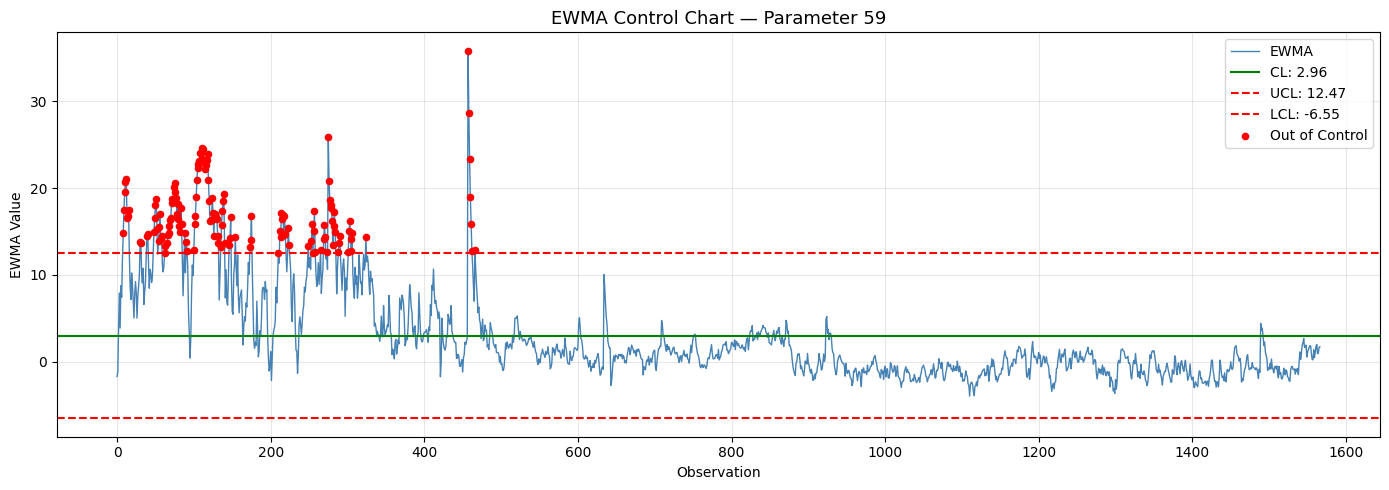

Out of control points (EWMA): 143


In [12]:
# EWMA Control Chart
lambda_ = 0.2  # smoothing parameter
L = 3  # sigma limit

data_individual = X_final[param].values
mean = data_individual.mean()
std = data_individual.std()

# Calculate EWMA values
ewma = np.zeros(len(data_individual))
ewma[0] = data_individual[0]
for i in range(1, len(data_individual)):
    ewma[i] = lambda_ * data_individual[i] + (1 - lambda_) * ewma[i-1]

# Control limits
UCL_ewma = mean + L * std * np.sqrt(lambda_ / (2 - lambda_))
LCL_ewma = mean - L * std * np.sqrt(lambda_ / (2 - lambda_))

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ewma, color='steelblue', linewidth=1, label='EWMA')
ax.axhline(mean, color='green', linewidth=1.5, label=f'CL: {mean:.2f}')
ax.axhline(UCL_ewma, color='red', linewidth=1.5, linestyle='--', label=f'UCL: {UCL_ewma:.2f}')
ax.axhline(LCL_ewma, color='red', linewidth=1.5, linestyle='--', label=f'LCL: {LCL_ewma:.2f}')

ooc_ewma = (ewma > UCL_ewma) | (ewma < LCL_ewma)
ax.scatter(np.where(ooc_ewma)[0], ewma[ooc_ewma], color='red', zorder=5, s=20, label='Out of Control')

ax.set_title(f'EWMA Control Chart — Parameter {param}', fontsize=13)
ax.set_ylabel('EWMA Value')
ax.set_xlabel('Observation')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ewma_chart_param59.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Out of control points (EWMA): {ooc_ewma.sum()}")